# Moment Scaling Analysis — Spatial Ensemble

This notebook implements the **moment scaling analysis** framework to characterize the statistical properties of seismic signals across different temporal windows and quantify their scaling behavior.

## Theoretical Framework

The moment scaling method (Beck & Cohen, 2003; Vollmer et al., 2024) analyzes how statistical moments of signal increments scale with time lag τ:

$$M_q(\tau) = \langle |\Delta x(\tau)|^q \rangle \sim \tau^{\zeta(q)}$$

where:
- $\Delta x(\tau) = x(t + \tau) - x(t)$ = signal increment at lag τ
- $q$ = moment order (0.25 ≤ q ≤ 5)
- $\langle \cdot \rangle$ = ensemble average over all stations/components
- $\zeta(q)$ = **scaling exponent** (quantifies diffusion regime)

## Physical Interpretation

The scaling exponent ζ(q) reveals the **diffusion regime**:

**Normal diffusion (Brownian motion):**
$$\zeta(q) = \frac{q}{2} \quad \text{(linear in q)}$$

**Anomalous diffusion:**
$$\zeta(q) \neq \frac{q}{2}$$

- **Subdiffusion:** ζ(q) < q/2 → slower than Brownian
- **Superdiffusion:** ζ(q) > q/2 → faster than Brownian

**Strongly anomalous diffusion (multifractal):**
$$\zeta(q) \text{ nonlinear in } q \quad \rightarrow \quad \text{intermittency, heavy tails}$$

**Heavy-tailed distributions:**
If ζ(q) saturates for large q → power-law tails with exponent α:
$$P(|\Delta x|) \sim |\Delta x|^{-(1+\alpha)}$$

## Spatial Ensemble Method

**Why ensemble?**
- Single-trace analysis: too noisy, limited statistics
- Ensemble averaging: robust estimation, reduces fluctuations

**Ensemble construction:**
- N = 66 independent traces (22 stations × 3 components)
- Each component treated as independent realization
- Justified by different wave polarizations captured

**Processing steps:**
1. For each window (pre-event, P, S, coda):
   - Compute increments: $\Delta x_i(\tau) = x_i(t_0 + \tau) - x_i(t_0)$ for station $i$
   - Pool all increments: $\{\Delta x_1(\tau), \Delta x_2(\tau), \ldots, \Delta x_N(\tau)\}$
   - Compute ensemble moment: $M_q(\tau) = N^{-1} \sum_{i=1}^N |\Delta x_i(\tau)|^q$

2. For each q:
   - Fit power law: $\log M_q(\tau) = \zeta(q) \log \tau + C$
   - Extract scaling exponent ζ(q) from linear regression

3. Analyze ζ(q) spectrum:
   - Check linearity (normal vs. anomalous)
   - Check convexity (multifractal signature)
   - Compare across windows and signal types

## Adaptive t₀ Selection

**Problem:** Window start times vary by station (different P/S arrival times).

**Solution:** For each station, set $t_0 = $ window start time:
- Pre-event: $t_0 = 0$
- P-wave: $t_0 = t_P$
- S-wave: $t_0 = t_S$
- Coda: $t_0 = t_{\text{coda}}$

This ensures all increments are computed **within** the relevant window.

## Tau Range Selection

**Challenge:** Window durations vary by station (close stations = short P-S times).

**Strategy:** Use τ values that fit **shortest window** across ensemble:
$$\tau_{\max} = \min_i(\text{duration}_i)$$

This ensures all stations contribute to all τ values (no missing data).

**Tau generation:**
- Logarithmically spaced: $\tau \in [0.01, \tau_{\max}]$ seconds
- Generated directly in **sample space**: `np.logspace(log10(tau_min_samples), log10(tau_max_samples), n_tau)`
- Converted to seconds only for output (avoids rounding errors)

## Analysis Workflow
Input: windowed_signals_{coda_method}_{picker}.pkl
1. Load signals for all 4 coda methods
2. For each coda method:

    a. For each window (pre-event, P, S, coda):

    - Find $\tau_{\text{max}}$ = min window duration
    - Compute increments for all stations
    - Calculate $M_q(\tau)$ for $q\in[0.25, 5]$
    - Fit $\zeta(q)$ via linear regression

    b. Save results:

    - Parquet: $M_q(\tau), \zeta(q), R^2,$ fit residuals
    - Figures: scaling curves, $\zeta(q)$ spectra

Output: 4 result sets (one per coda method)

**Dataset:** Windowed signals from notebooks 03a (AR-AIC) or 03b (PhaseNet), with 4 coda detection methods (Rautian, Arias, Envelope, Median).

**Outputs:**
- `data/processed/04a_moment_scaling_spatial/{picker}/{signal_type}/{coda_method}/`
  - `moments_*.parquet` — M_q(τ) for each window
  - `exponents_*.parquet` — ζ(q), R², confidence intervals
- `figures/04a_moment_scaling_spatial/{picker}/{signal_type}/{coda_method}/`
  - Scaling curves: log M_q vs. log τ
  - Exponent spectra: ζ(q) vs. q
  - Comparison plots across windows

## 1. Imports and visualization settings

In [35]:
from pathlib import Path
import pandas as pd
import logging
import numpy as np
import matplotlib.pyplot as plt
import pickle
from IPython.display import display
from src import (
    analyze_all_windows,
    save_results_parquet,
    plot_scaling_curves,
    plot_scaling_exponents,
    set_plot_style
)
colors, colors1 = set_plot_style()
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger()
def check(condition, message):
    if condition:
        logger.info(message)
    else:
        raise ValueError(message)
logger.info("Environment ready")

INFO | Environment ready


## 2. Configuration

Set `DATA_TYPE` and `PICKING_METHOD` to analyze specific signal type and phase picker combination.

**Available combinations:**
- Signal types: `acceleration`, `velocity`, `displacement`
- Pickers: `ar_pick`, `phasenet`

**Total analyses:** 3 signal types × 2 pickers × 4 coda methods = **24 result sets**

This notebook processes one combination at a time. Results are organized in separate directories to enable systematic comparison.

In [36]:
# CONFIGURATION
# EVENT_ID = 'INT-41004391'
EVENT_ID = 'IT-2009-0009'
DATA_TYPE = 'displacement'  # Options: 'acceleration', 'velocity', 'displacement'

# Determine signal column name and units based on DATA_TYPE
if DATA_TYPE == 'acceleration':
    SIGNAL_COLUMN = 'signal'
    SIGNAL_UNIT = 'cm/s²'
    PEAK_COLUMN = 'PGA_CM/S^2'
    TIME_PEAK_COLUMN = 'TIME_PGA_S'
elif DATA_TYPE == 'velocity':
    SIGNAL_COLUMN = 'signal'
    SIGNAL_UNIT = 'cm/s'
    PEAK_COLUMN = 'PGV_CM/S'
    TIME_PEAK_COLUMN = 'TIME_PGV_S'
elif DATA_TYPE == 'displacement':
    SIGNAL_COLUMN = 'signal'
    SIGNAL_UNIT = 'cm'
    PEAK_COLUMN = 'PGD_CM'
    TIME_PEAK_COLUMN = 'TIME_PGD_S'
else:
    raise ValueError(f"Unknown DATA_TYPE: {DATA_TYPE}")

logger.info(f"Working with {DATA_TYPE} data")
logger.info(f"Signal column: {SIGNAL_COLUMN}")
logger.info(f"Peak column: {PEAK_COLUMN}")

INFO | Working with displacement data
INFO | Signal column: signal
INFO | Peak column: PGD_CM


## 3. Data Loading

Load windowed signals for **all four coda detection methods** (Rautian, Arias, Envelope, Median).

### Input File Structure

Each pickle file contains a nested dictionary:

```python
windowed_signals = {
    'STATION_CODE': {
        'HNE': {
            'pre_event': {
                'signal': array([...]),      # Signal values
                'time': array([...]),        # Time axis (seconds)
                'start_samples': int,        # Window start (samples)
                'end_samples': int,          # Window end (samples)
                'start_seconds': float,      # Window start (seconds)
                'end_seconds': float,        # Window end (seconds)
                'duration_samples': int,     # Duration (samples)
                'duration_seconds': float    # Duration (seconds)
            },
            'p_wave': {...},
            's_wave': {...},
            'coda': {...}
        },
        'HNN': {...},
        'HNZ': {...}
    },
    ...
}
```

**Key features:**
- **4 windows per component** (pre-event, P, S, coda)
- **Dual representation:** Both samples (for computation) and seconds (for output)
- **Adaptive window starts:** Different $t_0$ per station/component

### Why Four Coda Methods?

To assess **sensitivity of scaling exponents to coda window definition**:
- Rautian: theoretical ($2t_S - t_0$)
- Arias: energy-based (D5-95)
- Envelope: amplitude-based (25% threshold)
- Median: robust combination

**Hypothesis:** ζ(q) should be **robust** to moderate coda timing shifts (~5-10 seconds).

In [37]:
PICKING_METHOD = 'ar_pick' # Options: 'ar_pick', 'phasenet'

# Get project root
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent

# Define all paths from project root
METADATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed' / EVENT_ID / '01a_metadata' / DATA_TYPE
if PICKING_METHOD == 'ar_pick':
    SIGNALS_PROCESSED_IMPORT = PROJECT_ROOT / 'data' / 'processed' / EVENT_ID / '03a_phase_identification_ar_pick' / DATA_TYPE
    SIGNALS_PROCESSED_EXPORT = PROJECT_ROOT / 'data' / 'processed' / EVENT_ID / '04a_moment_scaling_spatial' / 'ar_pick' / DATA_TYPE
    FIGURES_DIR = PROJECT_ROOT / 'figures' / EVENT_ID / '04a_moment_scaling_spatial' / 'ar_pick' / DATA_TYPE
elif PICKING_METHOD == 'phasenet':
    SIGNALS_PROCESSED_IMPORT = PROJECT_ROOT / 'data' / 'processed' / EVENT_ID / '03b_phase_identification_phasenet' / DATA_TYPE
    SIGNALS_PROCESSED_EXPORT = PROJECT_ROOT / 'data' / 'processed' / EVENT_ID / '04a_moment_scaling_spatial' / 'phasenet' / DATA_TYPE
    FIGURES_DIR = PROJECT_ROOT / 'figures' / EVENT_ID / '04a_moment_scaling_spatial' / 'phasenet' / DATA_TYPE
LATEX_TABLES_DIR = PROJECT_ROOT / 'data' / 'processed' / EVENT_ID / 'latex_tables'

# Create output directories
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METADATA_PROCESSED.mkdir(parents=True, exist_ok=True)
SIGNALS_PROCESSED_IMPORT.mkdir(parents=True, exist_ok=True)
SIGNALS_PROCESSED_EXPORT.mkdir(parents=True, exist_ok=True)
LATEX_TABLES_DIR.mkdir(parents=True, exist_ok=True)

check(FIGURES_DIR.exists(), f"Figures directory ready: {FIGURES_DIR}")
check(LATEX_TABLES_DIR.exists(), f"LaTeX tables directory ready: {LATEX_TABLES_DIR}")
check(METADATA_PROCESSED.exists(), f"Processed metadata directory ready: {METADATA_PROCESSED}")
check(SIGNALS_PROCESSED_IMPORT.exists(), f"Processed signals directory ready: {SIGNALS_PROCESSED_IMPORT}")
check(SIGNALS_PROCESSED_EXPORT.exists(), f"Processed signals export directory ready: {SIGNALS_PROCESSED_EXPORT}")

# Load windowed signals for all coda methods
logger.info(f"Loading {DATA_TYPE} windowed signals for all coda methods...")

input_file_rautian = SIGNALS_PROCESSED_IMPORT / f'windowed_{DATA_TYPE}_rautian_{PICKING_METHOD}.pkl'
with open(input_file_rautian, 'rb') as f:
    windowed_signals_rautian = pickle.load(f)
logger.info(f"Loaded: {input_file_rautian}")

input_file_arias = SIGNALS_PROCESSED_IMPORT / f'windowed_{DATA_TYPE}_arias_{PICKING_METHOD}.pkl'
with open(input_file_arias, 'rb') as f:
    windowed_signals_arias = pickle.load(f)
logger.info(f"Loaded: {input_file_arias}")

input_file_envelope = SIGNALS_PROCESSED_IMPORT / f'windowed_{DATA_TYPE}_envelope_{PICKING_METHOD}.pkl'
with open(input_file_envelope, 'rb') as f:
    windowed_signals_envelope = pickle.load(f)
logger.info(f"Loaded: {input_file_envelope}")

input_file_median = SIGNALS_PROCESSED_IMPORT / f'windowed_{DATA_TYPE}_median_{PICKING_METHOD}.pkl'
with open(input_file_median, 'rb') as f:
    windowed_signals_median = pickle.load(f)
logger.info(f"Loaded: {input_file_median}")

logger.info("All windowed signals loaded successfully")

INFO | Figures directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/04a_moment_scaling_spatial/ar_pick/displacement
INFO | LaTeX tables directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/IT-2009-0009/latex_tables
INFO | Processed metadata directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/IT-2009-0009/01a_metadata/displacement
INFO | Processed signals directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/IT-2009-0009/03a_phase_identification_ar_pick/displacement
INFO | Processed signals export directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/IT-2009-0009/04a_moment_scaling_spatial/ar_pick/displacement
INFO | Loading displacement windowed signals for all coda methods...
INFO | Loaded: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/dat

## 4. Analysis Parameters

Define moment orders (q) and time lag range (τ) for scaling analysis.

### Moment Orders (q)

```python
q_values = np.arange(0.25, 5.1, 0.25)  # 20 values from 0.25 to 5.0
```

**Rationale:**
- **Low q (0.25-1.0):** Sensitive to small increments, bulk distribution
- **q = 1:** Mean absolute increment (sensitive to central tendency)
- **q = 2:** Variance (standard measure of diffusion)
- **High q (3.0-5.0):** Sensitive to rare large events, tail behavior

**Trade-off:**
- More q values → better resolution of ζ(q) spectrum
- Fewer q values → faster computation, less noise in fits

### Time Lag Range (τ)

**Dynamic range:** Automatically determined per window to fit shortest duration across ensemble.

**Minimum lag:**
- `tau_min = 0.01 s` (2 samples at 200 Hz)
- Lower bound to avoid numerical artifacts
- Corresponds to highest frequency content (~50 Hz)

**Maximum lag:**
- `tau_max = min(window_durations)` across all stations
- Ensures all stations contribute to all τ values
- Typically:
  - Pre-event: ~5-10 s
  - P-wave: ~2-5 s
  - S-wave: ~5-15 s
  - Coda: ~50-200 s

**Number of τ points:**
- Automatically computed to achieve ~40-50 logarithmically spaced values
- More points → better power-law fit quality
- Fewer points → faster computation

**Note:** τ values are generated in **sample space** using `np.logspace`, then converted to seconds. This avoids rounding errors from seconds → samples conversions.

In [38]:
# q values: moment orders from 0.5 to 5.0
q_values = np.arange(0.25, 5.1, 0.25)
logger.info(f"q values defined: {len(q_values)} values from {q_values.min()} to {q_values.max()}")
logger.info(f"q values: {q_values}")

INFO | q values defined: 20 values from 0.25 to 5.0
INFO | q values: [0.25 0.5  0.75 1.   1.25 1.5  1.75 2.   2.25 2.5  2.75 3.   3.25 3.5
 3.75 4.   4.25 4.5  4.75 5.  ]


## 5. Moment Scaling Analysis

Compute moment scaling exponents ζ(q) for all windows using the spatial ensemble method.

### Algorithm

For each window $W$ ∈ {pre-event, P-wave, S-wave, coda}:

**Step 1: Find adaptive τ range**
```python
tau_max = min([window['duration_seconds'] for all stations])
tau_samples = np.logspace(log10(tau_min_samples), log10(tau_max_samples), n_tau)
```

**Step 2: Compute increments for each station $i$**
```python
for each tau:
    Delta_x_i(tau) = signal_i[t0 + tau] - signal_i[t0]
```
where $t_0 = $ window start time (station-specific).

**Step 3: Pool increments across ensemble**
```python
Delta_x(tau) = [Delta_x_1(tau), Delta_x_2(tau), ..., Delta_x_N(tau)]
```
with N = 51-66 (depending on QC failures).

**Step 4: Compute ensemble moments**
```python
for each q:
    M_q(tau) = mean(|Delta_x(tau)|^q)
```

**Step 5: Fit scaling exponent**
```python
log(M_q(tau)) = zeta(q) * log(tau) + C
```
Linear regression in log-log space → extract ζ(q) and R².

**Step 6: Save results**
- Parquet files: `moments_{window}.parquet`, `exponents_{window}.parquet`
- Figures: `scaling_curves_{window}.pdf`, `exponents_{window}.pdf`

### Output Structure

**Moments DataFrame** (`moments_{window}.parquet`):
| Column | Type | Description |
|--------|------|-------------|
| `tau_seconds` | float | Time lag (seconds) |
| `tau_samples` | int | Time lag (samples) |
| `q` | float | Moment order |
| `M_q` | float | Ensemble moment M_q(τ) |
| `n_increments` | int | Number of increments in ensemble |

**Exponents DataFrame** (`exponents_{window}.parquet`):
| Column | Type | Description |
|--------|------|-------------|
| `q` | float | Moment order |
| `zeta` | float | Scaling exponent ζ(q) |
| `zeta_stderr` | float | Standard error of ζ |
| `r_squared` | float | Fit quality (R²) |
| `intercept` | float | Fit intercept C |
| `n_tau` | int | Number of τ points used |

### Quality Metrics

**R² (coefficient of determination):**
- R² > 0.95 → excellent power-law fit
- 0.90 < R² < 0.95 → good fit
- R² < 0.90 → poor fit (check for crossovers or noise)

**Standard error:**
- Small σ(ζ) → robust estimate
- Large σ(ζ) → noisy data or short τ range

**Number of τ points:**
- More points → better statistics
- Typical range: 30-50 per window

### 5.1 Rautian Coda Method

Run moment scaling analysis using Rautian coda onset definition ($t_{\text{coda}} = 2t_S - t_0$).

ENSEMBLE SPATIAL SCALING ANALYSIS
tau_min: 0.500 s (fixed for all windows)
tau_max_fraction: None (use full window duration)
q_values: 20 values from 0.25 to 5.00
sampling_rate: 200.0 Hz

Processing window: PRE_EVENT
--------------------------------------------------------------------------------
Ensemble size: 99 signals
Tau range: [0.5000, 5.0250] s
Number of tau points: 30
Mean ζ(q): 2.4919 ± 1.0145
Mean R²: 0.9431
ζ(q=1): 1.4392
ζ(q=2): 2.2036

Processing window: P_WAVE
--------------------------------------------------------------------------------
Ensemble size: 126 signals
Tau range: [0.5000, 6.4800] s
Number of tau points: 30
Mean ζ(q): 5.4577 ± 3.1412
Mean R²: 0.9748
ζ(q=1): 1.8602
ζ(q=2): 4.0959

Processing window: S_WAVE
--------------------------------------------------------------------------------
Ensemble size: 180 signals
Tau range: [0.5000, 4.9150] s
Number of tau points: 30
Mean ζ(q): -0.4818 ± 0.4681
Mean R²: 0.4239
ζ(q=1): 0.0934
ζ(q=2): -0.2599

Processing window: 

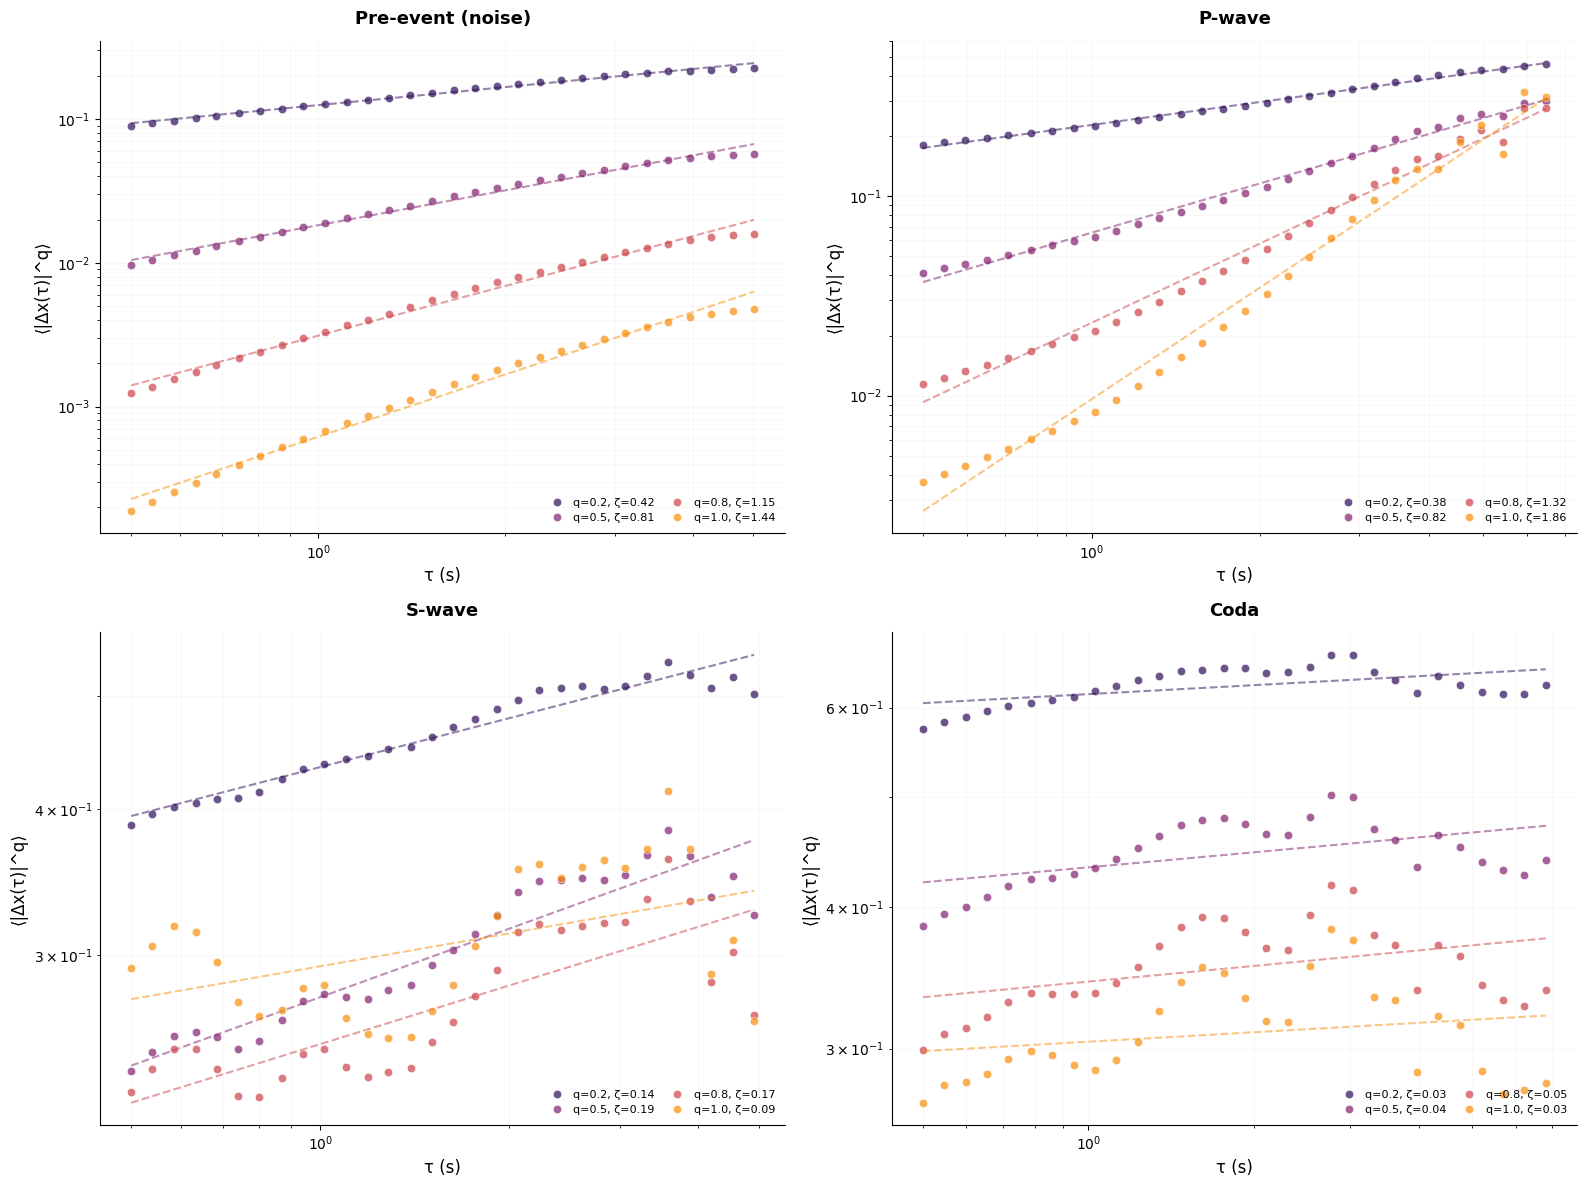

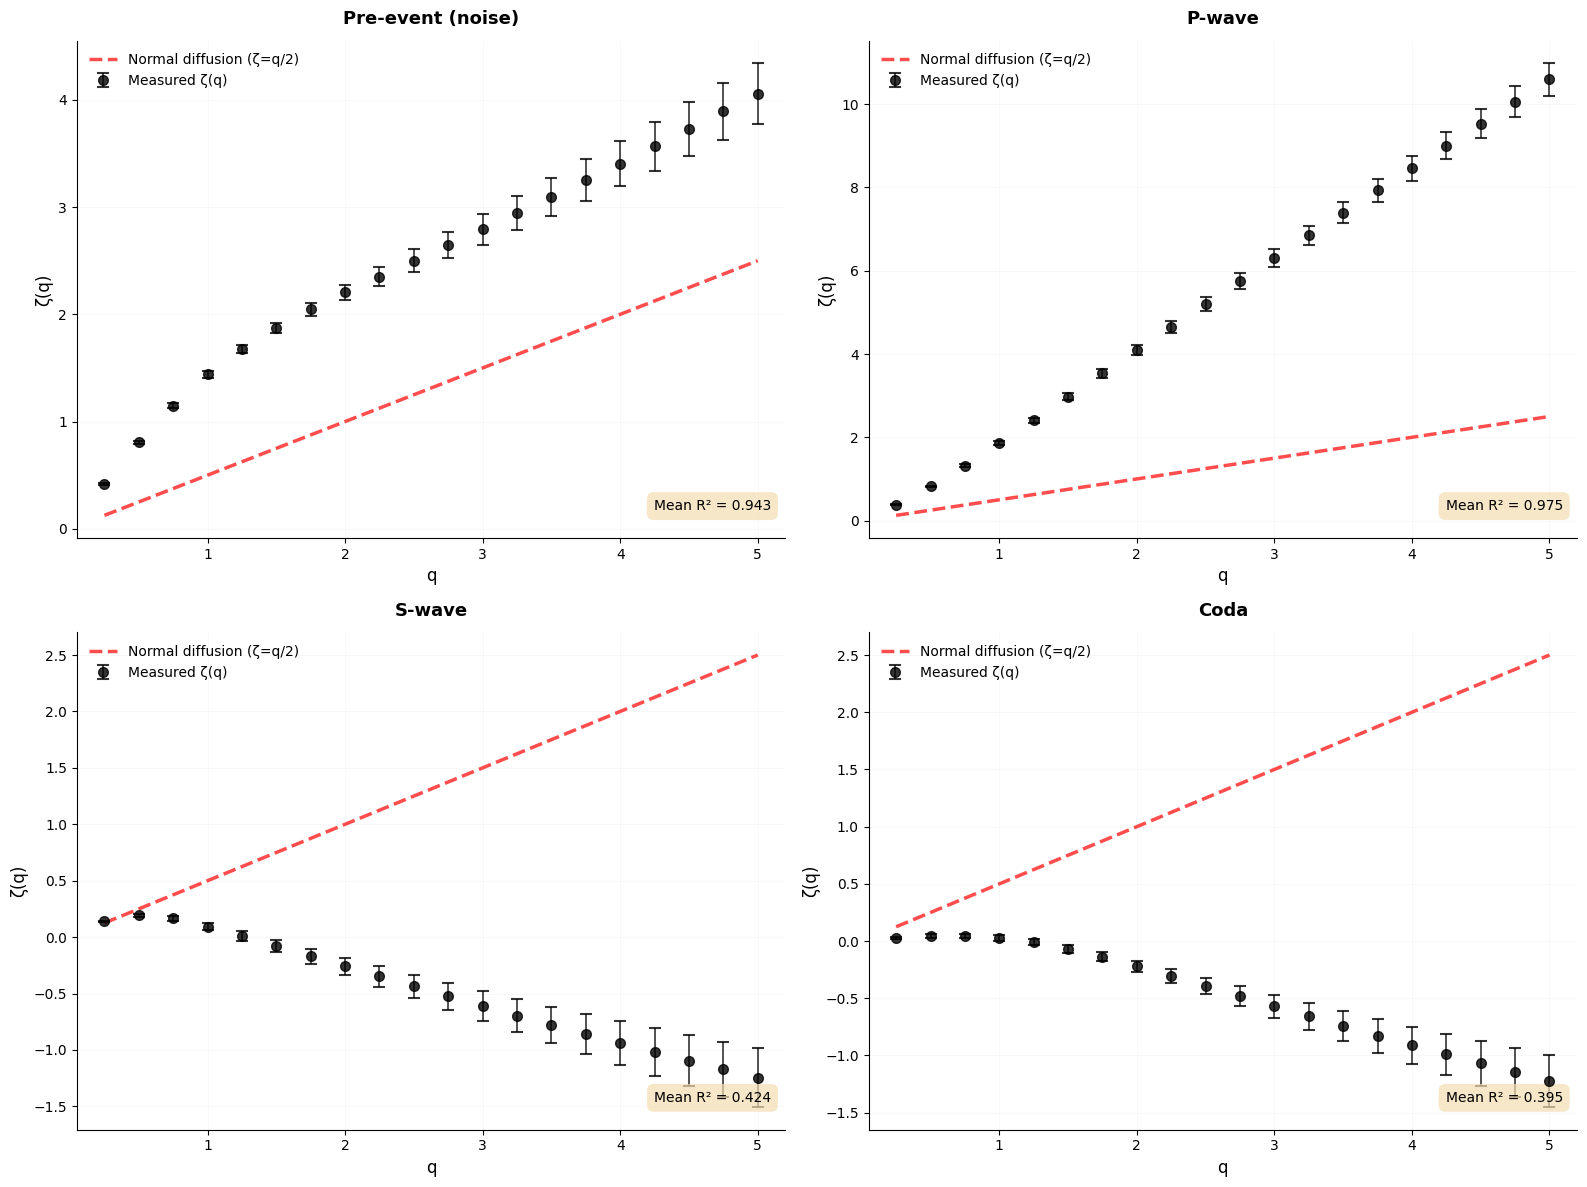

In [39]:
results_rautian = analyze_all_windows(
    windowed_signals_rautian,
    signal_field=SIGNAL_COLUMN,
    tau_min=0.5,
    n_tau=None,
    q_values=q_values,
    sampling_rate=200.0,
    fit_range=None
)

save_results_parquet(
    results_rautian, 
    output_dir=SIGNALS_PROCESSED_EXPORT / 'rautian'
)

fig1_rautian = plot_scaling_curves(
    results_rautian, 
    output_dir=FIGURES_DIR / 'rautian',
    q_subset=[0.25, 0.5, 0.75, 1]
)
fig2_rautian = plot_scaling_exponents(
    results_rautian,
    output_dir=FIGURES_DIR / 'rautian'
)

### 5.2 Arias Coda Method

Run moment scaling analysis using Arias Intensity D5-95 coda onset definition.

ENSEMBLE SPATIAL SCALING ANALYSIS
tau_min: 0.500 s (fixed for all windows)
tau_max_fraction: None (use full window duration)
q_values: 20 values from 0.25 to 5.00
sampling_rate: 200.0 Hz

Processing window: PRE_EVENT
--------------------------------------------------------------------------------
Ensemble size: 99 signals
Tau range: [0.5000, 5.0250] s
Number of tau points: 30
Mean ζ(q): 2.4919 ± 1.0145
Mean R²: 0.9431
ζ(q=1): 1.4392
ζ(q=2): 2.2036

Processing window: P_WAVE
--------------------------------------------------------------------------------
Ensemble size: 126 signals
Tau range: [0.5000, 6.4800] s
Number of tau points: 30
Mean ζ(q): 5.4577 ± 3.1412
Mean R²: 0.9748
ζ(q=1): 1.8602
ζ(q=2): 4.0959

Processing window: S_WAVE
--------------------------------------------------------------------------------
Ensemble size: 180 signals
Tau range: [0.5000, 3.1450] s
Number of tau points: 30
Mean ζ(q): -0.5029 ± 0.5055
Mean R²: 0.3801
ζ(q=1): 0.1155
ζ(q=2): -0.2589

Processing window: 

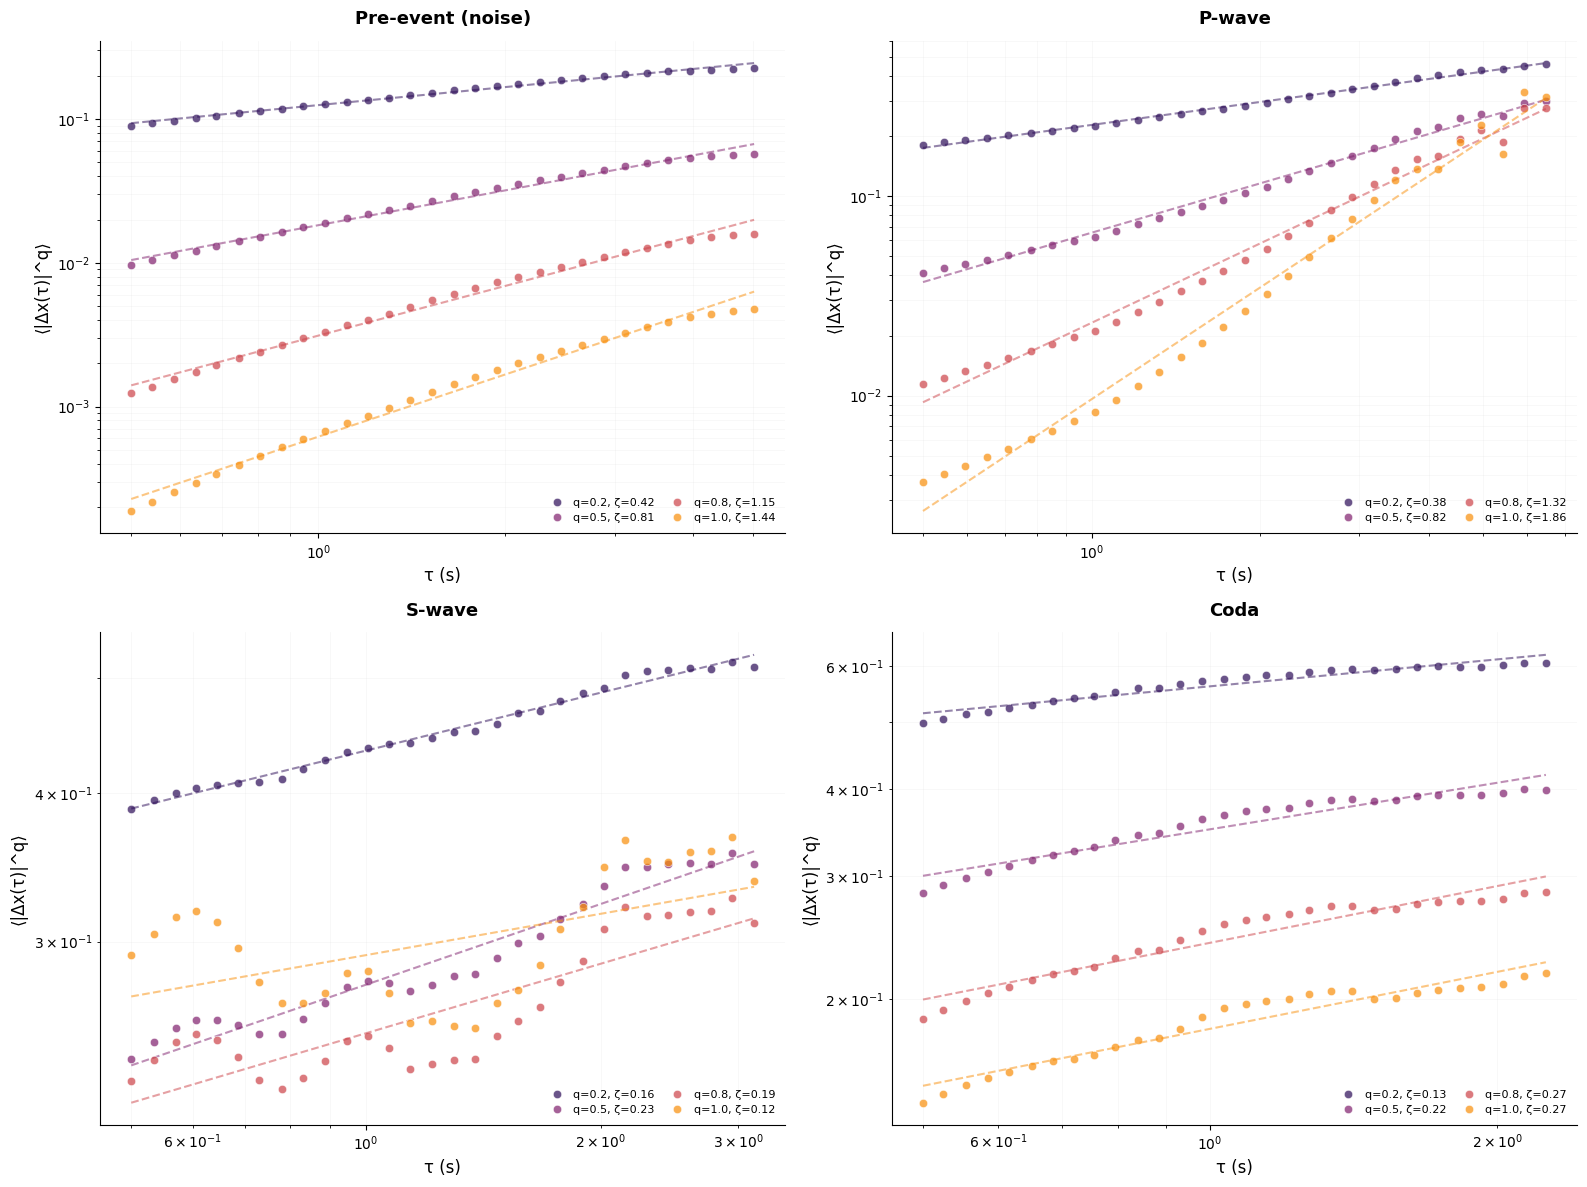

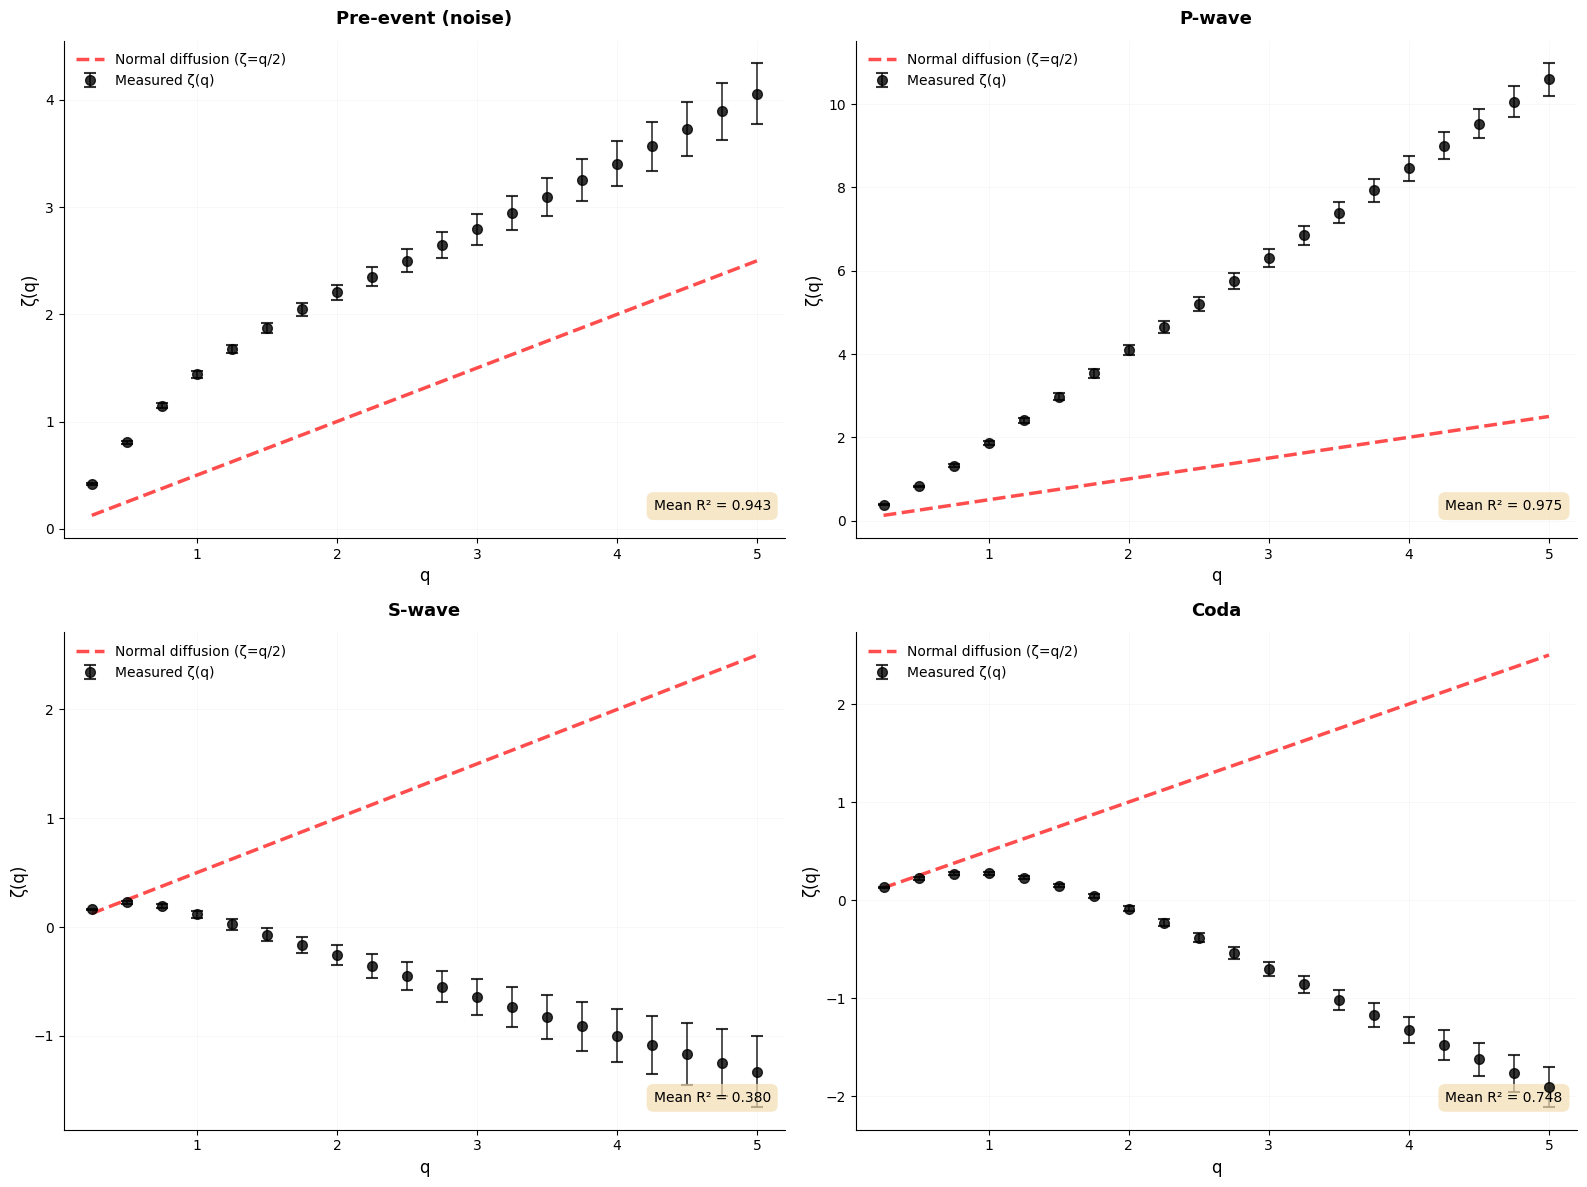

In [40]:
results_arias = analyze_all_windows(
    windowed_signals_arias,
    signal_field=SIGNAL_COLUMN,
    tau_min=0.5,
    n_tau=None,
    q_values=q_values,
    sampling_rate=200.0,
    fit_range=None
)

save_results_parquet(
    results_arias, 
    output_dir=SIGNALS_PROCESSED_EXPORT / 'arias'
)

fig1_arias = plot_scaling_curves(
    results_arias, 
    output_dir=FIGURES_DIR / 'arias',
    q_subset=[0.25, 0.5, 0.75, 1]
)
fig2_arias = plot_scaling_exponents(
    results_arias,
    output_dir=FIGURES_DIR / 'arias'
)

### 5.3 Envelope Coda Method

Run moment scaling analysis using envelope decay coda onset definition (25% threshold).

ENSEMBLE SPATIAL SCALING ANALYSIS
tau_min: 0.500 s (fixed for all windows)
tau_max_fraction: None (use full window duration)
q_values: 20 values from 0.25 to 5.00
sampling_rate: 200.0 Hz

Processing window: PRE_EVENT
--------------------------------------------------------------------------------
Ensemble size: 99 signals
Tau range: [0.5000, 5.0250] s
Number of tau points: 30
Mean ζ(q): 2.4919 ± 1.0145
Mean R²: 0.9431
ζ(q=1): 1.4392
ζ(q=2): 2.2036

Processing window: P_WAVE
--------------------------------------------------------------------------------
Ensemble size: 126 signals
Tau range: [0.5000, 6.4800] s
Number of tau points: 30
Mean ζ(q): 5.4577 ± 3.1412
Mean R²: 0.9748
ζ(q=1): 1.8602
ζ(q=2): 4.0959

Processing window: S_WAVE
--------------------------------------------------------------------------------
Ensemble size: 165 signals
Tau range: [0.5000, 2.1350] s
Number of tau points: 30
Mean ζ(q): -0.4756 ± 0.5553
Mean R²: 0.4286
ζ(q=1): 0.1528
ζ(q=2): -0.1574

Processing window: 

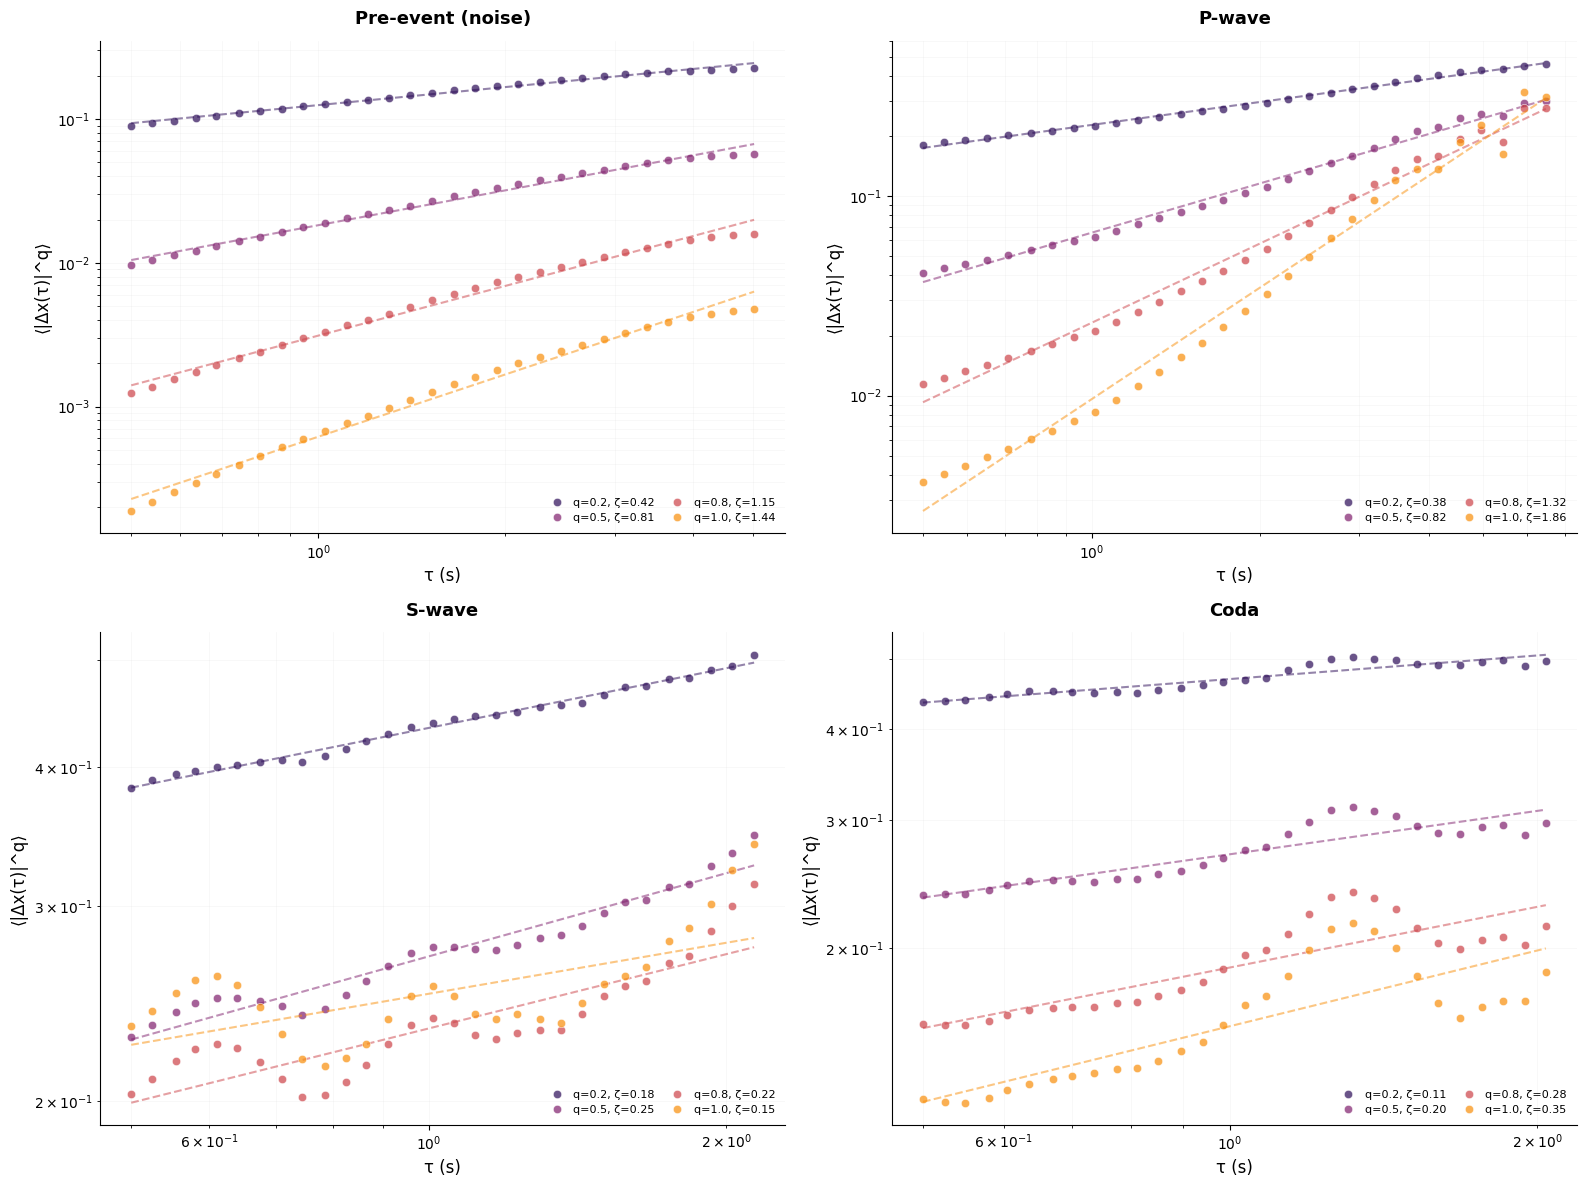

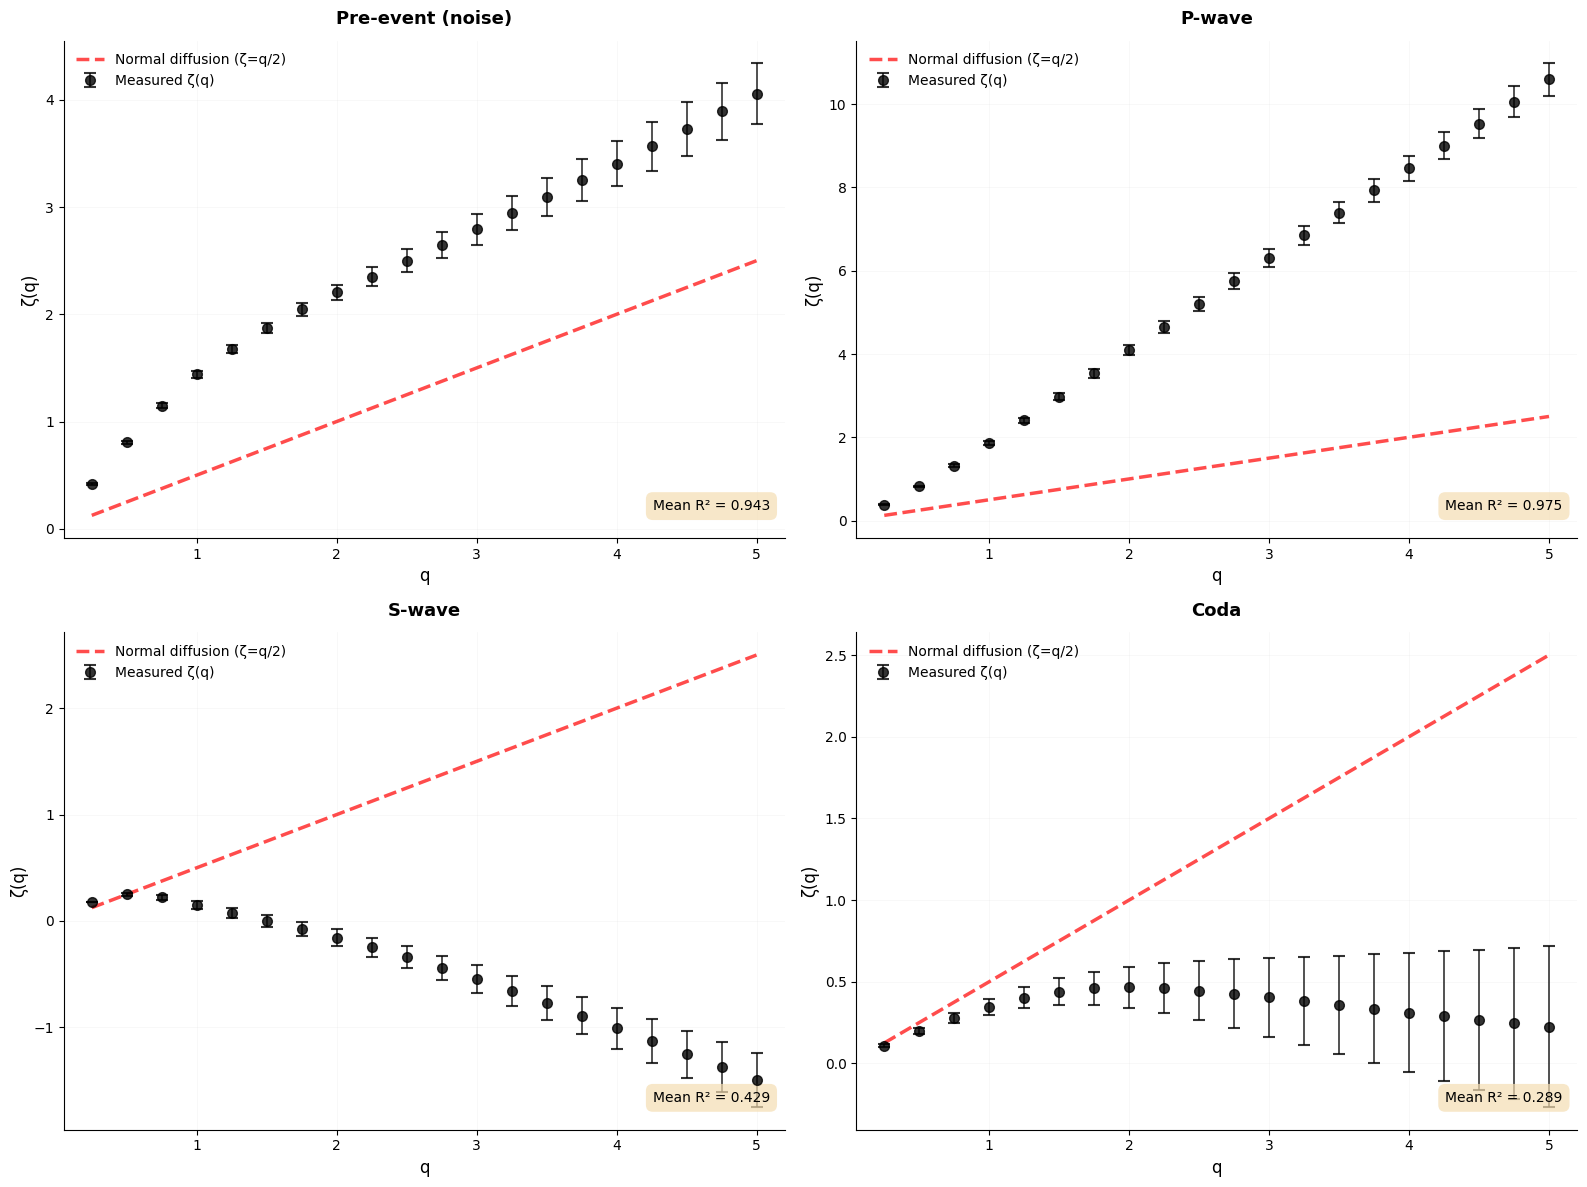

In [41]:
results_envelope = analyze_all_windows(
    windowed_signals_envelope,
    signal_field=SIGNAL_COLUMN,
    tau_min=0.5,
    n_tau=None,
    q_values=q_values,
    sampling_rate=200.0,
    fit_range=None
)

save_results_parquet(
    results_envelope, 
    output_dir=SIGNALS_PROCESSED_EXPORT / 'envelope'
)

fig1_envelope = plot_scaling_curves(
    results_envelope, 
    output_dir=FIGURES_DIR / 'envelope',
    q_subset=[0.25, 0.5, 0.75, 1]
)
fig2_envelope = plot_scaling_exponents(
    results_envelope,
    output_dir=FIGURES_DIR / 'envelope'
)

### 5.4 Median Coda Method

Run moment scaling analysis using median of the three coda methods above.

ENSEMBLE SPATIAL SCALING ANALYSIS
tau_min: 0.500 s (fixed for all windows)
tau_max_fraction: None (use full window duration)
q_values: 20 values from 0.25 to 5.00
sampling_rate: 200.0 Hz

Processing window: PRE_EVENT
--------------------------------------------------------------------------------
Ensemble size: 99 signals
Tau range: [0.5000, 5.0250] s
Number of tau points: 30
Mean ζ(q): 2.4919 ± 1.0145
Mean R²: 0.9431
ζ(q=1): 1.4392
ζ(q=2): 2.2036

Processing window: P_WAVE
--------------------------------------------------------------------------------
Ensemble size: 126 signals
Tau range: [0.5000, 6.4800] s
Number of tau points: 30
Mean ζ(q): 5.4577 ± 3.1412
Mean R²: 0.9748
ζ(q=1): 1.8602
ζ(q=2): 4.0959

Processing window: S_WAVE
--------------------------------------------------------------------------------
Ensemble size: 180 signals
Tau range: [0.5000, 3.5800] s
Number of tau points: 30
Mean ζ(q): -0.4007 ± 0.4396
Mean R²: 0.3463
ζ(q=1): 0.1461
ζ(q=2): -0.1874

Processing window: 

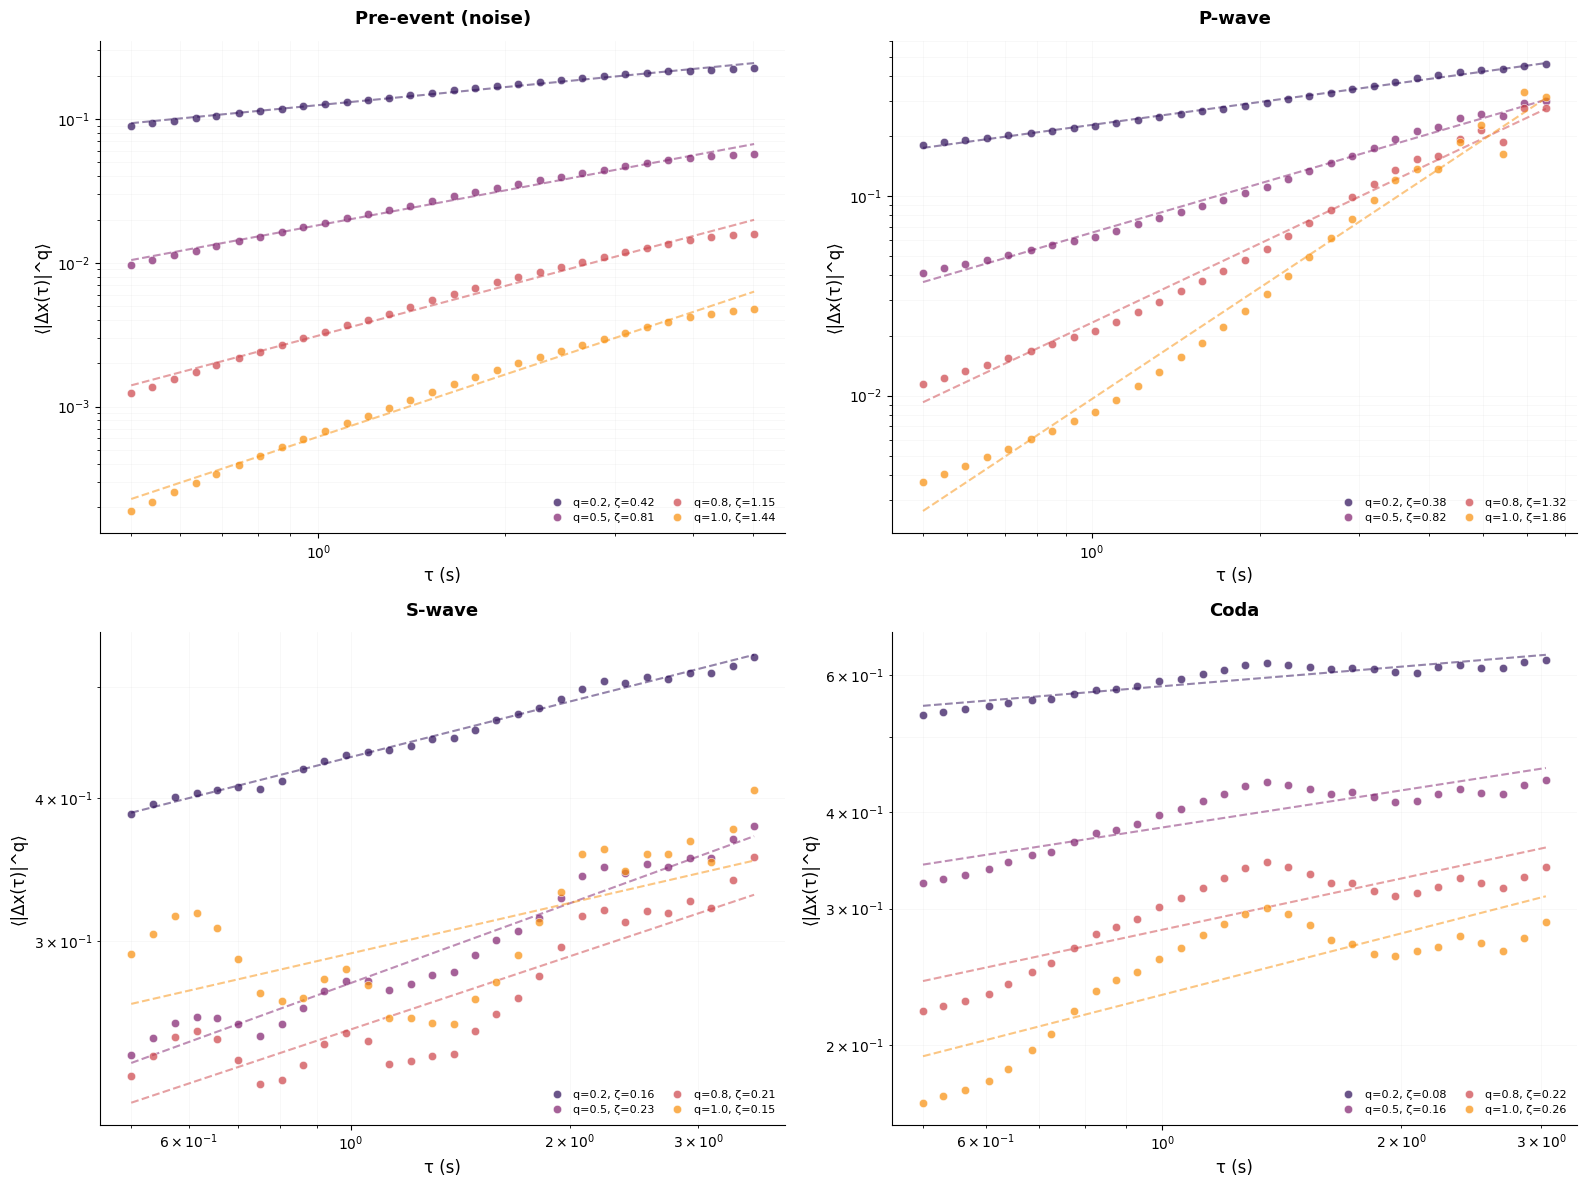

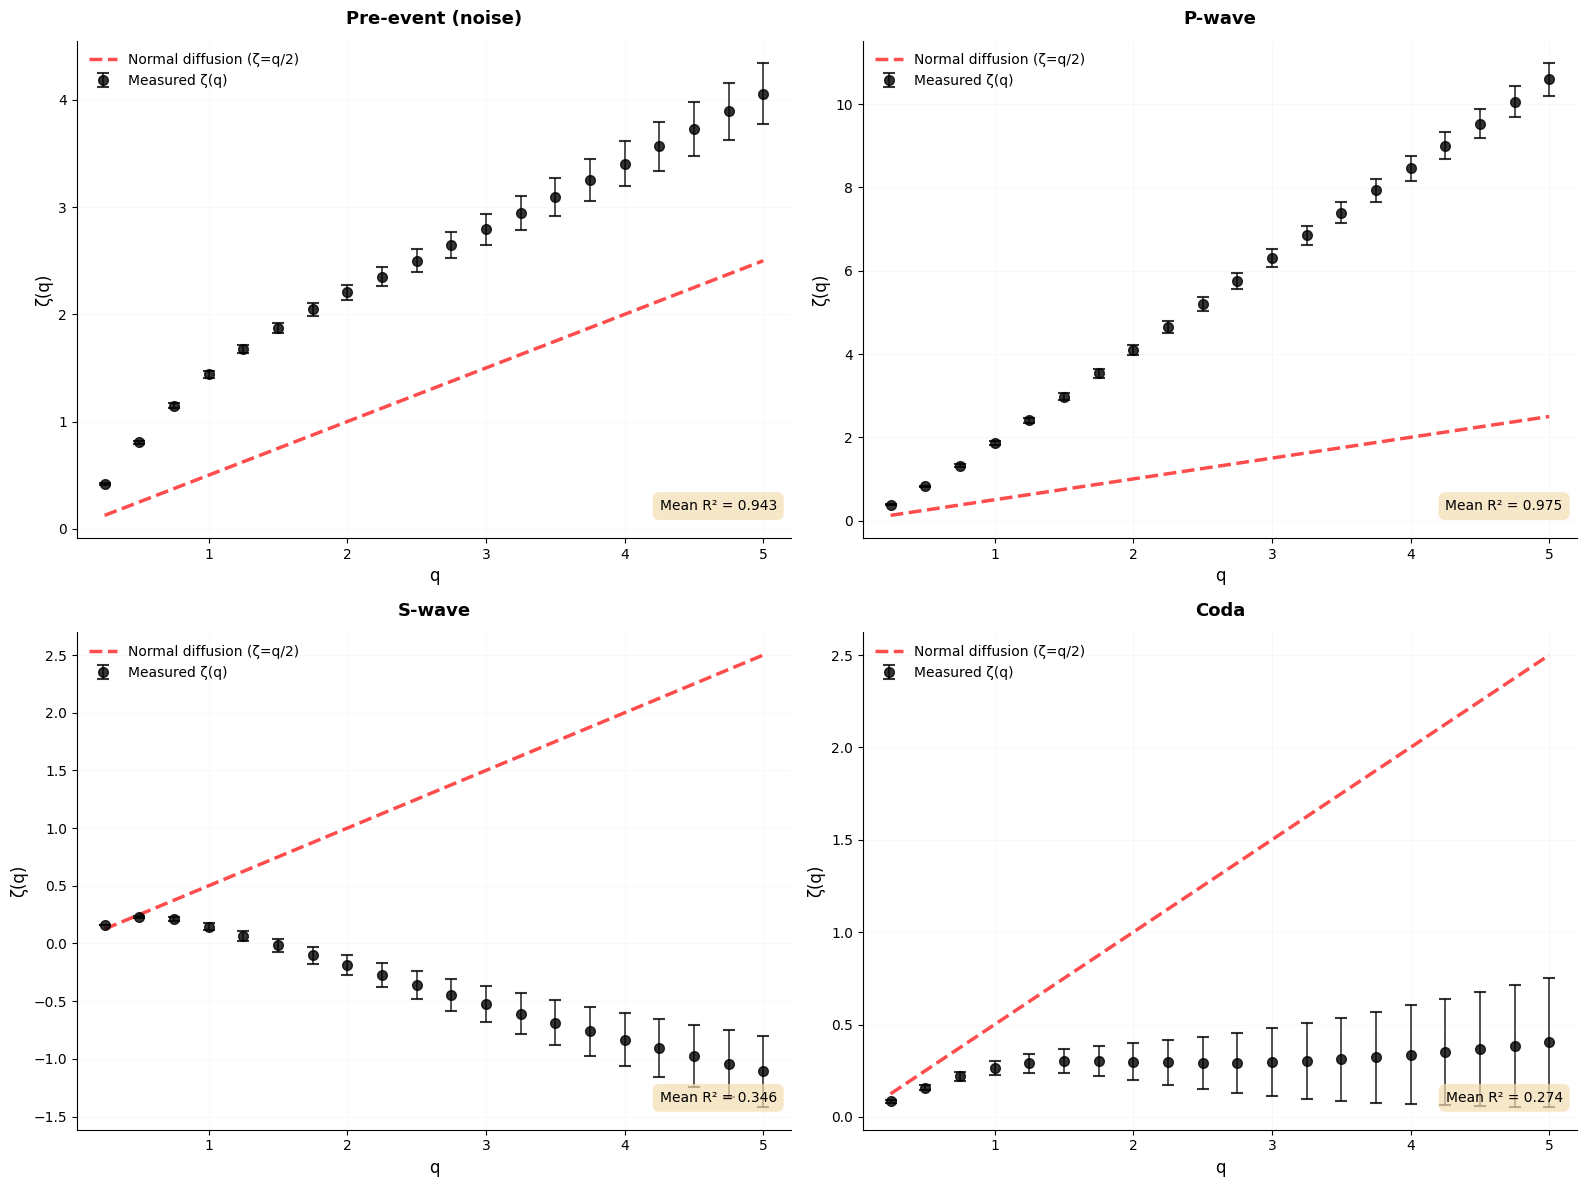

In [42]:
results_median = analyze_all_windows(
    windowed_signals_median,
    signal_field=SIGNAL_COLUMN,
    tau_min=0.5,
    n_tau=None,
    q_values=q_values,
    sampling_rate=200.0,
    fit_range=None
)

save_results_parquet(
    results_median, 
    output_dir=SIGNALS_PROCESSED_EXPORT / 'median'
)

fig1_median = plot_scaling_curves(
    results_median, 
    output_dir=FIGURES_DIR / 'median',
    q_subset=[0.25, 0.5, 0.75, 1]
)
fig2_median = plot_scaling_exponents(
    results_median,
    output_dir=FIGURES_DIR / 'median'
)

## 6. Summary and Comparison

Compare moment scaling results across the four coda detection methods to assess robustness.

### Key Questions

1. **Are ζ(q) values consistent across coda methods?**
   - Expected variation: ±0.05-0.10 in ζ(q)
   - Larger differences → coda window definition matters

2. **Which windows show strongest anomalous diffusion?**
   - Pre-event: normal diffusion baseline (ζ ≈ q/2)
   - P/S-wave: moderate anomaly
   - Coda: strongest anomaly (multifractal signature)

3. **Do results depend on phase picker (AR-AIC vs. PhaseNet)?**
   - Run this notebook twice (once per picker)
   - Compare ζ(q) spectra between pickers
   - Assess impact of systematic timing differences

### Expected Findings

**Pre-event window:**
- ζ(q) ≈ 0.5·q (linear, normal diffusion)
- R² > 0.98 (excellent power-law fit)
- Independent of coda method (pre-event before any phases)

**P-wave window:**
- ζ(q) slightly > 0.5·q (weak superdiffusion)
- Possible slight nonlinearity for large q
- Robust across coda methods (P-window ends at S-arrival)

**S-wave window:**
- ζ(q) >> 0.5·q (strong superdiffusion)
- May show nonlinearity (peak amplitudes → heavy tails)
- **Sensitive to coda method** (S-window end = coda start)
  - Rautian → earliest coda → longest S-window
  - Arias → latest coda → shortest S-window
  - Difference: ~5-10 seconds

**Coda window:**
- ζ(q) strongly nonlinear (multifractal)
- Saturation at large q (power-law tails)
- **Moderately sensitive to coda method**
  - Different start times → different ensemble composition
  - Expected variation: Δζ(q) ~ 0.1-0.2


### Next Steps

1. Run analysis for all combinations:
   - 3 signal types × 2 pickers × 4 coda methods = 24 runs
   
2. Create comparative plots (notebook 04b or 05):
   - ζ(q) spectra overlaid for all coda methods
   - Δζ(q) = ζ(q) - q/2 deviation plots
   - Heatmaps: ζ(q) vs. (window, coda_method)

3. Statistical tests:
   - ANOVA: ζ(q) differences across coda methods
   - Confidence intervals on ζ(q)
   - Bootstrap resampling for uncertainty

4. Physical interpretation:
   - Connect ζ(q) to diffusion regime classification
   - Relate multifractality to scattering processes
   - Compare with published seismic scaling studies

In [43]:
import pickle
with open(SIGNALS_PROCESSED_IMPORT / f'windowed_{DATA_TYPE}_rautian_{PICKING_METHOD}.pkl', 'rb') as f:
    ws = pickle.load(f)

for station in ws:
    for component in ws[station]:
        if 's_wave' in ws[station][component]:
            w = ws[station][component]['s_wave']
            if len(w['signal']) != w['duration_samples']:
                print(f"{station} {component}: len={len(w['signal'])}, duration_samples={w['duration_samples']}")

In [44]:
import pandas as pd
df_full = pd.read_parquet(SIGNALS_PROCESSED_IMPORT / f'df_full_{DATA_TYPE}_ar_pick.parquet')
df_full[df_full['STATION_CODE'] == 'GNL'][['STATION_CODE', 'COMPONENT', 
    't_s_detected_samples', 't_coda_rautian_samples', 
    't_coda_end_rautian_samples']].head(3)

,STATION_CODE,COMPONENT,t_s_detected_samples,t_coda_rautian_samples,t_coda_end_rautian_samples
84,GNL,HNE,146,14092,NaN
85,GNL,HNN,146,14092,NaN
86,GNL,HNZ,146,14092,NaN
